In [1]:
"""
This script is used to plot the CRE-QTLs
authors: Roy Oelen
"""

'\nThis script is used to plot the CRE-QTLs\nauthors: Roy Oelen\n'

In [2]:
# for checking file locations
import os
import glob
import os.path
# use warnings
import warnings
# use regex
import re
# get pandas plink info
from pandas_plink import read_plink1_bin
# for pandas
import pandas as pd
# for making the scatterplot
import seaborn as sns
import matplotlib.pyplot as plt
# for doing z score transformations
from scipy.stats import zscore

In [3]:
def get_interaction_table(omics_1, omics_2, genotypes, omics_1_smf, omics_2_smf, omics_1_feature, omics_2_feature, variant):
    """
    Generate a table of interactions between two omics layers and genotype data.

    Parameters:
    omics_1 (pd.DataFrame): First omics ayer with samples as columns.
    omics_2 (pd.DataFrame): Second omics ayer with samples as columns.
    genotypes (xr.Dataset): Genotype data with samples and variants.
    omics_1_smf (pd.DataFrame): Sample mapping file for the first omics ayer.
    omics_2_smf (pd.DataFrame): Sample mapping file for the second omics ayer.
    omics_1_feature (str): Feature name in the first omics layer.
    omics_2_feature (str): Feature name in the second omics layer.
    variant (str): Variant identifier in the genotype data.

    Returns:
    pd.DataFrame: A DataFrame containing the samples, omics values, and genotype information.
    """
    # get the samples from omics1
    samples_omics1 = list(omics_1.columns)
    # same for omics 2
    samples_omics2 = list(omics_2.columns)
    # now get which are present in both
    samples_omics = set(samples_omics1).intersection(samples_omics2)
    # now repeat that for the smf files
    smf_samples1 = omics_1_smf['phenotype_id'].tolist()
    smf_samples2 = omics_2_smf['phenotype_id'].tolist()
    smf_both = set(smf_samples1).intersection(smf_samples2)
    # finally get the omics and smf intersect
    samples_all = set(smf_both).intersection(samples_omics)
    # get the samples that are in the genotype data
    genotype_samples = genotypes.sample.to_numpy().tolist()
    # find the genotypes for the phenotypes
    samples_in_genotypes = omics_1_smf[omics_1_smf['genotype_id'].isin(genotype_samples)]['phenotype_id']
    # finally subset to samples we have genotype data for
    samples_everything = list(set(samples_all).intersection(samples_in_genotypes.tolist()))
    # get the value for both omics
    omics1_values = omics_1.loc[[omics_1_feature]][samples_everything].transpose()[omics_1_feature].tolist()
    omics2_values = omics_2.loc[[omics_2_feature]][samples_everything].transpose()[omics_2_feature].tolist()
    # get the genotypes
    genotype_names = omics_1_smf.loc[samples_in_genotypes.index.tolist()]['genotype_id'].tolist()
    # get the index of the variant in the genotype object
    variant_index = genotypes.variant.to_numpy().tolist()[genotypes.snp.to_numpy().tolist().index(variant)]
    # select the unique genotype names
    genotype_names_unique = list(set(genotype_names))
    # get the values
    genotype_values = genotypes.sel(sample = genotype_names_unique, variant = variant_index).to_numpy()
    # make unique samples and respective genotypes into dataframe
    genotypeid_to_genotype = pd.DataFrame({'genotype_id' : genotype_names_unique, 'genotype' : genotype_values})
    # make plot frame
    plot_frame = pd.DataFrame({'sample' : samples_everything, 'omics1' : omics1_values, 'omics2' : omics2_values})
    # join to the smf on the phenotype_id
    plot_frame = plot_frame.merge(omics_1_smf, how = 'left', left_on = 'sample', right_on = 'phenotype_id')
    # and then onto the genotypes
    plot_frame = plot_frame.merge(genotypeid_to_genotype, how = 'left', left_on = 'genotype_id', right_on = 'genotype_id')
    return plot_frame


def get_qtl_table(omics, genotypes, omics_smf, omics_feature, variant):
    """
    Generate a plottable QTL (Quantitative Trait Loci) table by integrating omics data with genotype data.

    Parameters:
    omics (pd.DataFrame): Omics dataset with samples as columns.
    genotypes (xr.Dataset): Genotype data with samples and variants.
    omics_smf (pd.DataFrame): Sample mapping file for the omics dataset.
    omics_feature (str): Feature name in the omics dataset.
    variant (str): Variant identifier in the genotype data.

    Returns:
    pd.DataFrame: A DataFrame containing the samples, omics values, and genotype information.
    """
    # get the samples from omics
    samples_omics = list(omics.columns)
    # get the samples in the smf
    smf_samples = omics_smf['phenotype_id'].tolist()
    # finally get the omics and smf intersect
    samples_all = set(smf_samples).intersection(samples_omics)
    # get the samples that are in the genotype data
    genotype_samples = genotypes.sample.to_numpy().tolist()
    # find the genotypes for the phenotypes
    samples_in_genotypes = omics_smf[omics_smf['genotype_id'].isin(genotype_samples)]['phenotype_id']
    # finally subset to samples we have genotype data for
    samples_everything = list(set(samples_all).intersection(samples_in_genotypes.tolist()))
    # get the value for both omics
    omics_values = omics.loc[[omics_feature]][samples_everything].transpose()[omics_feature].tolist()
    # get the genotypes
    genotype_names = omics_smf.loc[samples_in_genotypes.index.tolist()]['genotype_id'].tolist()
    # get the index of the variant in the genotype object
    variant_index = genotypes.variant.to_numpy().tolist()[genotypes.snp.to_numpy().tolist().index(variant)]
    # select the unique genotype names
    genotype_names_unique = list(set(genotype_names))
    # get the values
    genotype_values = genotypes.sel(sample = genotype_names_unique, variant = variant_index).to_numpy()
    # make unique samples and respective genotypes into dataframe
    genotypeid_to_genotype = pd.DataFrame({'genotype_id' : genotype_names_unique, 'genotype' : genotype_values})
    # make plot frame
    plot_frame = pd.DataFrame({'sample' : samples_everything, 'omics' : omics_values})
    # join to the smf on the phenotype_id
    plot_frame = plot_frame.merge(omics_smf, how = 'left', left_on = 'sample', right_on = 'phenotype_id')
    # and then onto the genotypes
    plot_frame = plot_frame.merge(genotypeid_to_genotype, how = 'left', left_on = 'genotype_id', right_on = 'genotype_id')
    return plot_frame


class InteractionPlotQuery:
    """
    A class to represent a query for interaction plots.

    Attributes
    ----------
    gene : str
        The gene of interest for the interaction plot.
    region : str
        The genomic region of interest for the interaction plot.
    variant : str
        The variant associated with the interaction plot.

    Methods
    -------
    __init__(self, gene, region, variant):
        Initializes the InteractionPlotQuery with the specified gene, region, and variant.
    """
    def __init__(self, gene, region, variant):
        """
        Constructs all the necessary attributes for the InteractionPlotQuery object.

        Parameters
        ----------
        gene : str
            The gene of interest for the interaction plot.
        region : str
            The genomic region of interest for the interaction plot.
        variant : str
            The variant associated with the interaction plot.
        """
        self.gene = gene
        self.region = region
        self.variant = variant


def interaction_plots_to_list(omics1, omics2, smf1, smf2, genotypes, plot_queries):
    """
    Generates interaction plots based on the provided omics data and plot queries.

    Parameters
    ----------
    omics1 : DataFrame
        The first omics dataset (e.g., RNA-seq data).
    omics2 : DataFrame
        The second omics dataset (e.g., ATAC-seq data).
    smf1 : DataFrame
        The single-molecule footprinting data for the first omics dataset.
    smf2 : DataFrame
        The single-molecule footprinting data for the second omics dataset.
    genotypes : DataFrame
        The genotype data.
    plot_queries : list of InteractionPlotQuery
        A list of InteractionPlotQuery objects containing the gene, region, and variant for each plot.

    """
    # create a list to put the interactions in
    interaction_plots_list = []
    # check each plot query
    for interaction_query in plot_queries:
        # remap the 0/1/2 genotypes to alleles
        mapping = {
            0 : ''.join([variant.split(':')[2], variant.split(':')[2]]), 
            1 : ''.join([variant.split(':')[2], variant.split(':')[3]]),
            2 : ''.join([variant.split(':')[3], variant.split(':')[3]])
        }
        # get interaction table
        interaction_table = get_interaction_table(
            omics_1=rna_nk_data, 
            omics_2=atac_nk_data, 
            genotypes=genotypes, 
            omics_1_smf=rna_smf, 
            omics_2_smf=atac_smf, 
            omics_1_feature=interaction_query.gene, 
            omics_2_feature=interaction_query.region, 
            variant=interaction_query.variant
        )
        # use remapping for alleles
        interaction_table['alleles'] = interaction_table['genotype'].map(mapping)
        # plot the without the interaction
        fig = plt.figure(figsize=(10, 6))
        sns.lmplot(data=interaction_table, x='omics2', y='omics1', hue='alleles', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
        plt.title('Gene expression vs open chromatin')
        plt.xlabel(' '.join(['Normalized chromatin openness at', interaction_query.region]))
        plt.ylabel(' '.join(['Normalized ', interaction_query.gene, ' gene expression']))
        plt.grid(True)
        # save plot
        plt.figure()


def top_creqtls_to_queries(cre_output_table, how_many=10, sort_by='p_value', sort_ascending=True, gene_column='feature_id', variant_column='snp_id', region_column='interaction_term'):
    """
    Converts the top entries from a cRE-QTL output table into a list of InteractionPlotQuery objects.

    Parameters
    ----------
    cre_output_table : DataFrame
        The cRE-QTL output table containing the data.
    how_many : int, optional
        The number of top entries to convert (default is 10).
    sort_by : str, optional
        The column name to sort the table by (default is 'p_value').
    sort_ascending : bool, optional
        Whether to sort the table in ascending order (default is True).
    gene_column : str, optional
        The column name for the gene feature (default is 'feature_id').
    variant_column : str, optional
        The column name for the variant (default is 'snp_id').
    region_column : str, optional
        The column name for the interaction term (default is 'interaction_term').

    Returns
    -------
    list
        A list of InteractionPlotQuery objects representing the top entries.
    """
    # sort the table
    cre_output_table_sorted = cre_output_table.sort_values(by = sort_by, ascending = sort_ascending)
    # check the number of rows
    n_rows_to_take = len(cre_output_table_sorted.index)
    # take less if the number of rows exceeds our top
    if n_rows_to_take > how_many:
        n_rows_to_take = how_many
    # subset to how many rows we want
    cre_output_table_sorted = cre_output_table_sorted.head(n_rows_to_take)
    # get the columns
    genes = cre_output_table_sorted[gene_column].tolist()
    variants = cre_output_table_sorted[variant_column].tolist()
    regions = cre_output_table_sorted[region_column].tolist()
    # make a list of queries
    queries = []
    # create each query
    for i in range(0, n_rows_to_take, 1):
        queries.append(InteractionPlotQuery(genes[i], regions[i], variants[i]))
    # return this set of queries
    return queries
    
    



In [4]:
# location of plink input files
plink_files_base_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/genotype/imputed_hg38_all_anc.bed'
# read the original genotype data
genotypes = read_plink1_bin(plink_files_base_loc)

Mapping files:   0%|                                                                                                                                                                           | 0/3 [00:00<?, ?it/s]

Mapping files: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [01:05<00:00, 21.79s/it]


In [5]:
# location of the expression data
rna_data_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/interaction_eqtl/sc-eqtlgen/input/L1/combined/monocyte.qtlInput.txt.gz'
#rna_data_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/eqtl/sc-eqtlgen/input/L1/UT/monocyte.qtlInput.PcCorrectedResiduals.txt.gz'
# read the RNA data
rna_data = pd.read_csv(rna_data_loc, header = 0, sep = '\t', index_col = 0)

In [6]:
# location of the ATAC data
atac_data_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/interaction_caqtl/sc-eqtlgen/input/L1/monocyte.qtlInput.txt.gz'
#atac_data_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/caqtl/sc-eqtlgen/input/L1/UT/monocyte.qtlInput.txt.gz'
# read the ATAC data
atac_data = pd.read_csv(atac_data_loc, header = 0, sep = '\t', index_col = 0)

In [7]:
# location of the g2e
atac_smf_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/interaction_caqtl/sc-eqtlgen/input/L1/smf.txt'
# for both of them
rna_smf_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/interaction_eqtl/sc-eqtlgen/input/L1/combined/smf.txt'
# read both of them
atac_smf = pd.read_csv(atac_smf_loc, header = 0, sep = '\t')
rna_smf = pd.read_csv(rna_smf_loc, header = 0, sep = '\t')

<Figure size 1000x600 with 0 Axes>

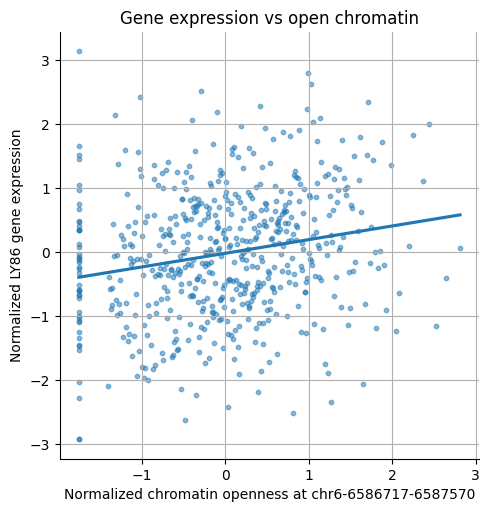

In [8]:
# just the top CRE
interaction_table = get_interaction_table(omics_1=rna_data, 
                 omics_2=atac_data, 
                 genotypes=genotypes, 
                 omics_1_smf=rna_smf, 
                 omics_2_smf=atac_smf, 
                 omics_1_feature='LY86', 
                 omics_2_feature='chr6-6586717-6587570', 
                 variant='6:6586961:A:G')
# plot the without the interaction
plt.figure(figsize=(10, 6))
sns_p = sns.lmplot(data=interaction_table, x='omics2', y='omics1', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin')
plt.xlabel('Normalized chromatin openness at chr6-6586717-6587570')
plt.ylabel('Normalized LY86 gene expression')
plt.grid(True)
plt.show()
sns_p.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_cre.pdf')

In [9]:
# remove personal information
#interaction_table = interaction_table.drop(labels = ['sample', 'genotype_id', 'genotype_id', 'genotype', 'phenotype_id'], axis = 1)
# rename some
interaction_table = interaction_table.rename({'omics1' : 'RNA', 'omics2' : 'ATAC'}, axis = 1)
# write the input of this table somewhere
interaction_table.to_csv('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/tables/gwenny_interaction_table2.tsv.gz', sep = '\t', index = False, header = True, compression = 'gzip')

In [10]:
# get the caQTL table
caqtl_table = get_qtl_table(omics=atac_data, 
                 genotypes=genotypes, 
                 omics_smf=atac_smf, 
                 omics_feature='chr6-6586717-6587570', 
                 variant='6:6586961:A:G')
# add a binary genotype
caqtl_table['Genotype'] = caqtl_table['genotype'].map({0.0 : 'A/A', 1.0 : 'A/G', 2.0 : 'G/G'})
# and sort
caqtl_table = caqtl_table.sort_values('Genotype')


In [11]:
# get the caQTL table
eqtl_table = get_qtl_table(omics=rna_data, 
                 genotypes=genotypes, 
                 omics_smf=rna_smf, 
                 omics_feature='LY86', 
                 variant='6:6586961:A:G')
# add a binary genotype
eqtl_table['Genotype'] = eqtl_table['genotype'].map({0.0 : 'A/A', 1.0 : 'A/G', 2.0 : 'G/G'})
# and sort
eqtl_table = eqtl_table.sort_values('Genotype')


In [12]:
# get the interaction table
interaction_table = get_interaction_table(omics_1=rna_data, 
                 omics_2=atac_data, 
                 genotypes=genotypes, 
                 omics_1_smf=rna_smf, 
                 omics_2_smf=atac_smf, 
                 omics_1_feature='LY86', 
                 omics_2_feature='chr6-6586717-6587570', 
                 variant='6:6586961:A:G')
# add a binary genotype
interaction_table['Genotype'] = interaction_table['genotype'].map({0.0 : 'A/A', 1.0 : 'A/G', 2.0 : 'G/G'})
interaction_table = interaction_table.sort_values('Genotype')


In [13]:
# get the location of the annotations for stimulation status
stim_status_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/metadata/mo_sample_to_stim.tsv.gz'
# read the stimulation status
stim_status = pd.read_csv(stim_status_loc, header = 0, sep = '\t', index_col = 0)
# add the sample identier in the interaction format to the status table
stim_status['sample_lane'] = stim_status['donor'] + ';;' + stim_status['lane']
# add the stimulation status to the interaction table
interaction_table = interaction_table.merge(stim_status[['sample_lane', 'condition']], how = 'left', left_on = 'sample', right_on = 'sample_lane')
# and the qtl tables
caqtl_table = caqtl_table.merge(stim_status[['sample_lane', 'condition']], how = 'left', left_on = 'sample', right_on = 'sample_lane')
eqtl_table = eqtl_table.merge(stim_status[['sample_lane', 'condition']], how = 'left', left_on = 'sample', right_on = 'sample_lane')


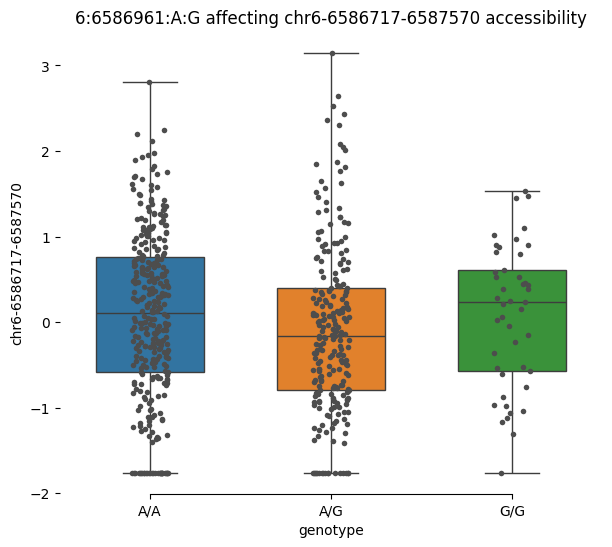

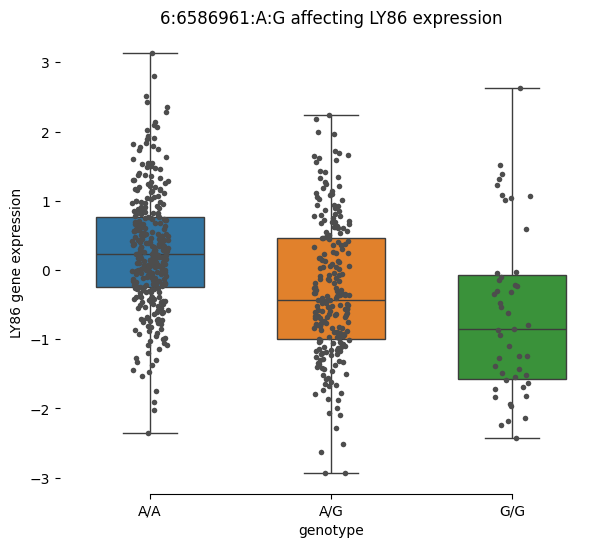

<Figure size 1000x600 with 0 Axes>

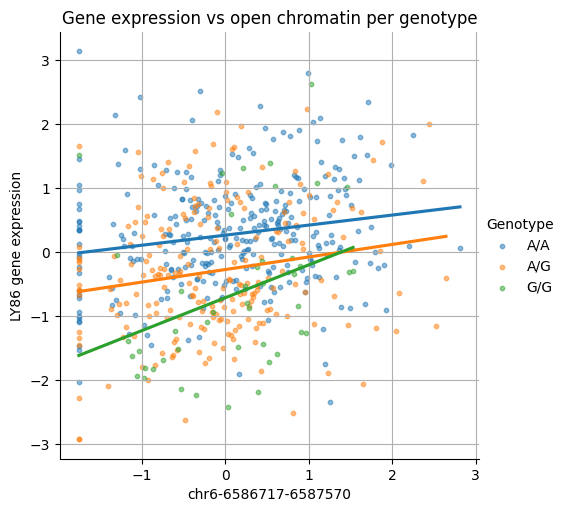

<Figure size 1000x600 with 0 Axes>

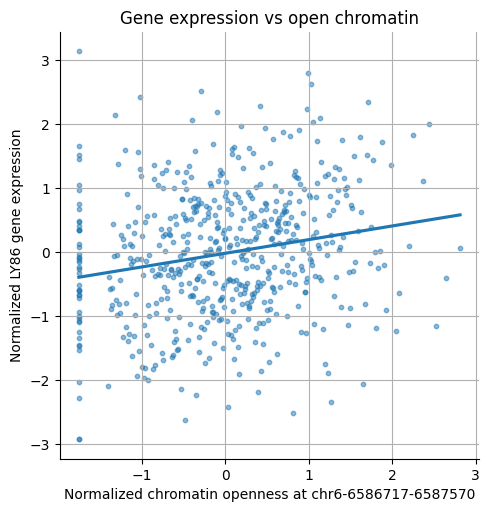

<Figure size 1000x600 with 0 Axes>

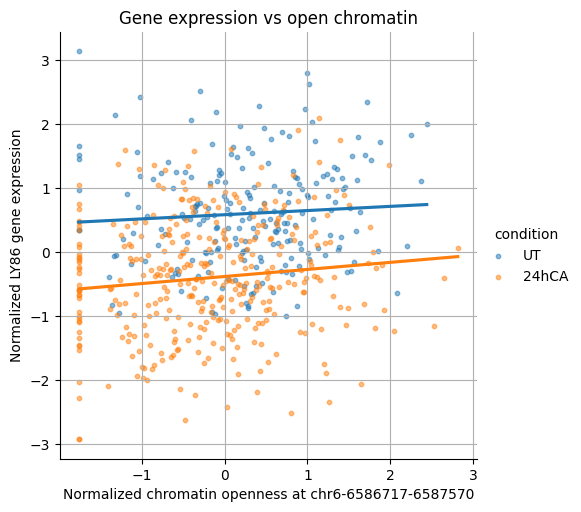

In [14]:
# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="Genotype", y="omics", hue="Genotype", data=caqtl_table, whis=[0, 100], width=.6).set(title = ' '.join(['6:6586961:A:G', 'affecting', 'chr6-6586717-6587570', 'accessibility']))
# Add in points to show each observation
sp = sns.stripplot(x="Genotype", y="omics", data=caqtl_table, size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='chr6-6586717-6587570', xlabel='genotype')
sns.despine(trim=True, left=True)
f.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_caqtl.pdf')

# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="Genotype", y="omics", hue="Genotype", data=eqtl_table, whis=[0, 100], width=.6).set(title = ' '.join(['6:6586961:A:G', 'affecting', 'LY86', 'expression']))
# Add in points to show each observation
sp = sns.stripplot(x="Genotype", y="omics", data=eqtl_table, size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='LY86 gene expression', xlabel='genotype')
sns.despine(trim=True, left=True)
f.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_eqtl.pdf')

# plot the interaction
plt.figure(figsize=(10, 6))
sns_p = sns.lmplot(data=interaction_table, x='omics2', y='omics1', hue='Genotype', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin per genotype')
plt.xlabel('chr6-6586717-6587570')
plt.ylabel('LY86 gene expression')
plt.grid(True)
plt.show()
sns_p.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_interaction_gt.pdf')

# plot the without the interaction
plt.figure(figsize=(10, 6))
sns_p = sns.lmplot(data=interaction_table, x='omics2', y='omics1', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin')
plt.xlabel('Normalized chromatin openness at chr6-6586717-6587570')
plt.ylabel('Normalized LY86 gene expression')
plt.grid(True)
plt.show()
sns_p.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_interaction.pdf')

plt.figure(figsize=(10, 6))
sns_p = sns.lmplot(data=interaction_table, x='omics2', y='omics1', hue='condition', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin')
plt.xlabel('Normalized chromatin openness at chr6-6586717-6587570')
plt.ylabel('Normalized LY86 gene expression')
plt.grid(True)
plt.show()
sns_p.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_interaction_condition_condition.pdf')


In [15]:
# write the input of this table somewhere
interaction_table.to_csv('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/tables/mo_monocyte_LY86_creqtl_example.tsv.gz', sep = '\t', index = False, header = True, compression = 'gzip')
# write the input of this table somewhere
caqtl_table.to_csv('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/tables/mo_monocyte_LY86_caqtl_table1.tsv.gz', sep = '\t', index = False, header = True, compression = 'gzip')
# write the input of this table somewhere
eqtl_table.to_csv('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/tables/mo_monocyte_LY86_eqtl_table1.tsv.gz', sep = '\t', index = False, header = True, compression = 'gzip')

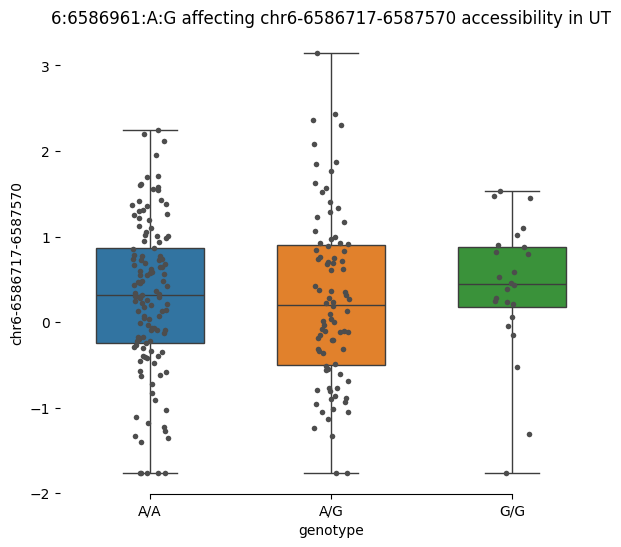

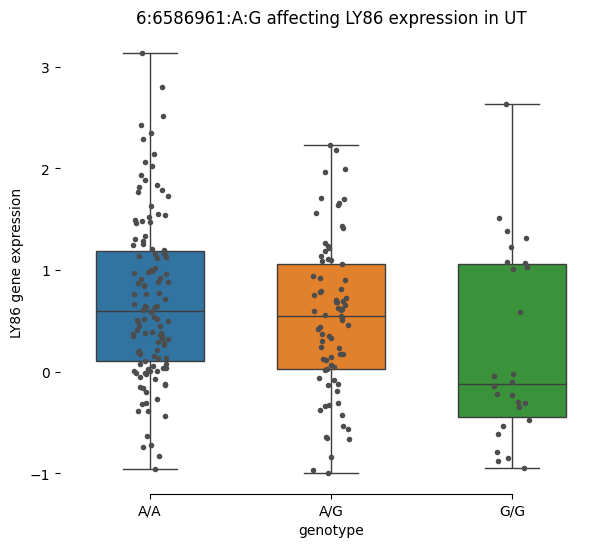

<Figure size 1000x600 with 0 Axes>

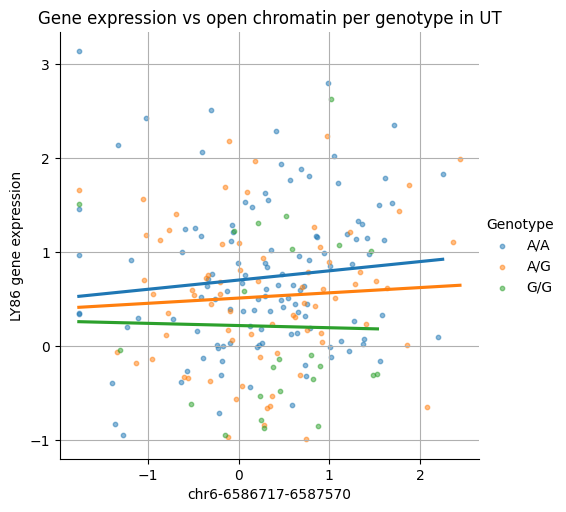

<Figure size 1000x600 with 0 Axes>

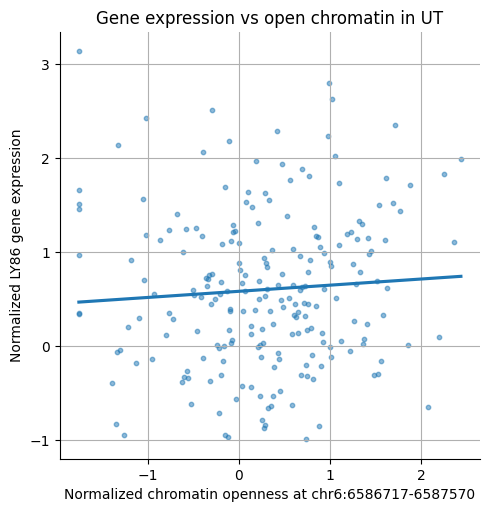

In [16]:
# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="Genotype", y="omics", hue="Genotype", data=caqtl_table[caqtl_table['condition'] == 'UT'], whis=[0, 100], width=.6).set(title = ' '.join(['6:6586961:A:G', 'affecting', 'chr6-6586717-6587570', 'accessibility', 'in UT']))
# Add in points to show each observation
sp = sns.stripplot(x="Genotype", y="omics", data=caqtl_table[caqtl_table['condition'] == 'UT'], size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='chr6-6586717-6587570', xlabel='genotype')
sns.despine(trim=True, left=True)
f.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_caqtl_ut.pdf')

# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="Genotype", y="omics", hue="Genotype", data=eqtl_table[eqtl_table['condition'] == 'UT'], whis=[0, 100], width=.6).set(title = ' '.join(['6:6586961:A:G', 'affecting', 'LY86', 'expression', 'in UT']))
# Add in points to show each observation
sp = sns.stripplot(x="Genotype", y="omics", data=eqtl_table[eqtl_table['condition'] == 'UT'], size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='LY86 gene expression', xlabel='genotype')
sns.despine(trim=True, left=True)
f.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_eqtl_ut.pdf')

# plot the interaction
plt.figure(figsize=(10, 6))
sns_p = sns.lmplot(data=interaction_table[interaction_table['condition'] == 'UT'], x='omics2', y='omics1', hue='Genotype', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin per genotype in UT')
plt.xlabel('chr6-6586717-6587570')
plt.ylabel('LY86 gene expression')
plt.grid(True)
plt.show()
sns_p.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_interaction_gt_ut.pdf')

# plot the without the interaction
plt.figure(figsize=(10, 6))
sns_p = sns.lmplot(data=interaction_table[interaction_table['condition'] == 'UT'], x='omics2', y='omics1', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin in UT')
plt.xlabel('Normalized chromatin openness at chr6:6586717-6587570')
plt.ylabel('Normalized LY86 gene expression')
plt.grid(True)
plt.show()
sns_p.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_interaction_ut.pdf')

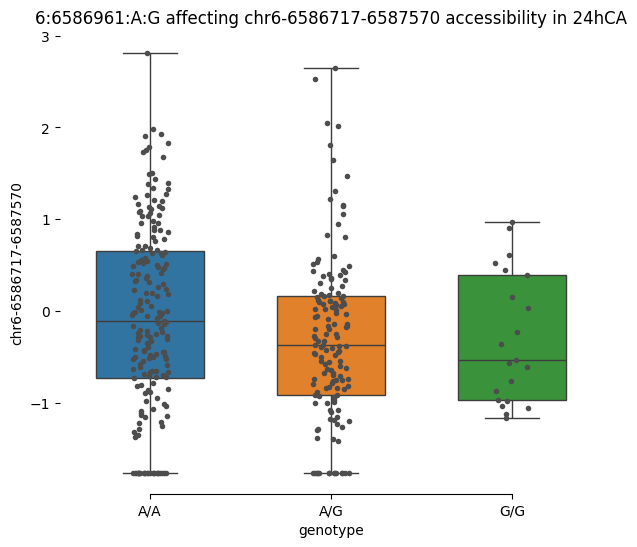

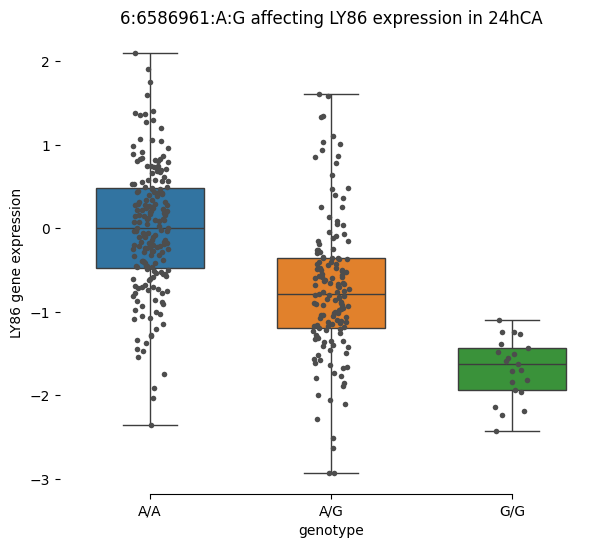

<Figure size 1000x600 with 0 Axes>

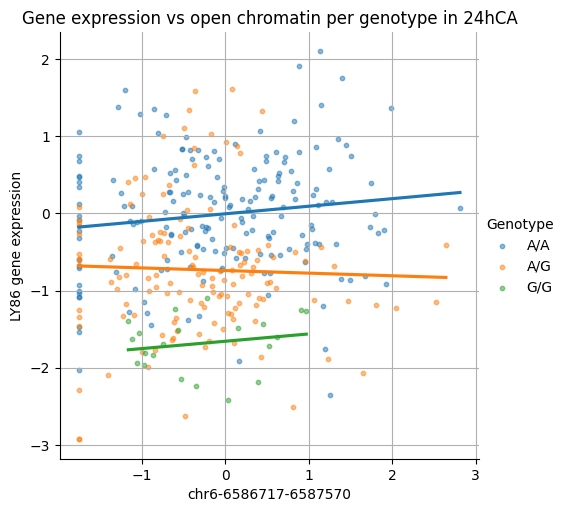

<Figure size 1000x600 with 0 Axes>

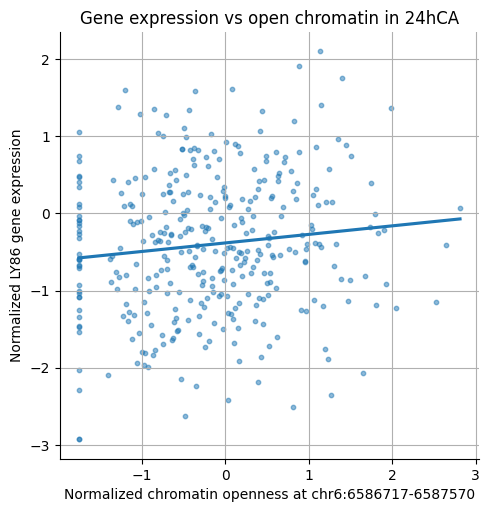

In [17]:
# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="Genotype", y="omics", hue="Genotype", data=caqtl_table[caqtl_table['condition'] == '24hCA'], whis=[0, 100], width=.6).set(title = ' '.join(['6:6586961:A:G', 'affecting', 'chr6-6586717-6587570', 'accessibility', 'in 24hCA']))
# Add in points to show each observation
sp = sns.stripplot(x="Genotype", y="omics", data=caqtl_table[caqtl_table['condition'] == '24hCA'], size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='chr6-6586717-6587570', xlabel='genotype')
sns.despine(trim=True, left=True)
f.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_caqtl_24hca.pdf')

# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="Genotype", y="omics", hue="Genotype", data=eqtl_table[eqtl_table['condition'] == '24hCA'], whis=[0, 100], width=.6).set(title = ' '.join(['6:6586961:A:G', 'affecting', 'LY86', 'expression', 'in 24hCA']))
# Add in points to show each observation
sp = sns.stripplot(x="Genotype", y="omics", data=eqtl_table[eqtl_table['condition'] == '24hCA'], size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='LY86 gene expression', xlabel='genotype')
sns.despine(trim=True, left=True)
f.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_eqtl_24hca.pdf')

# plot the interaction
plt.figure(figsize=(10, 6))
sns_p = sns.lmplot(data=interaction_table[interaction_table['condition'] == '24hCA'], x='omics2', y='omics1', hue='Genotype', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin per genotype in 24hCA')
plt.xlabel('chr6-6586717-6587570')
plt.ylabel('LY86 gene expression')
plt.grid(True)
plt.show()
sns_p.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_interaction_gt_24hca.pdf')

# plot the without the interaction
plt.figure(figsize=(10, 6))
sns_p = sns.lmplot(data=interaction_table[interaction_table['condition'] == '24hCA'], x='omics2', y='omics1', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin in 24hCA')
plt.xlabel('Normalized chromatin openness at chr6:6586717-6587570')
plt.ylabel('Normalized LY86 gene expression')
plt.grid(True)
plt.show()
sns_p.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_monocyte_ly86_interaction_24hca.pdf')


In [27]:
# location of the expression data
rna_data_b_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/interaction_eqtl/sc-eqtlgen/input/L1/combined/B.qtlInput.txt.gz'
# read the RNA data
rna_data_b = pd.read_csv(rna_data_b_loc, header = 0, sep = '\t', index_col = 0)
# location of the ATAC data
atac_data_b_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/interaction_caqtl/sc-eqtlgen/input/L1/B.qtlInput.txt.gz'
# read the ATAC data
atac_data_b = pd.read_csv(atac_data_b_loc, header = 0, sep = '\t', index_col = 0)

In [37]:
# get the eQTL table
eqtl_table_b = get_qtl_table(omics=rna_data_b, 
                 genotypes=genotypes, 
                 omics_smf=rna_smf, 
                 omics_feature='LY86', 
                 variant='6:6586961:A:G')
# add a binary genotype
eqtl_table_b['Genotype'] = eqtl_table_b['genotype'].map({0.0 : 'AA', 1.0 : 'AG', 2.0 : 'GG'})
# and sort
eqtl_table_b = eqtl_table_b.sort_values('Genotype')

In [38]:
# get the caQTL table
caqtl_table_b = get_qtl_table(omics=atac_data_b, 
                 genotypes=genotypes, 
                 omics_smf=atac_smf, 
                 omics_feature='chr6-6586717-6587570', 
                 variant='6:6586961:A:G')
# add a binary genotype
caqtl_table_b['Genotype'] = caqtl_table_b['genotype'].map({0.0 : 'A/A', 1.0 : 'A/G', 2.0 : 'G/G'})
# and sort
caqtl_table_b = caqtl_table_b.sort_values('Genotype')

In [39]:
# get the interaction table
interaction_table_b = get_interaction_table(omics_1=rna_data_b, 
                 omics_2=atac_data_b, 
                 genotypes=genotypes, 
                 omics_1_smf=rna_smf, 
                 omics_2_smf=atac_smf, 
                 omics_1_feature='LY86', 
                 omics_2_feature='chr6-6586717-6587570', 
                 variant='6:6586961:A:G')
# add a binary genotype
interaction_table_b['Genotype'] = interaction_table_b['genotype'].map({0.0 : 'A/A', 1.0 : 'A/G', 2.0 : 'G/G'})
interaction_table_b = interaction_table_b.sort_values('Genotype')

In [ ]:
# add the stimulation status to the interaction table
interaction_table_b = interaction_table_b.merge(stim_status[['sample_lane', 'condition']], how = 'left', left_on = 'sample', right_on = 'sample_lane')
# and the qtl tables
eqtl_table_b = eqtl_table_b.merge(stim_status[['sample_lane', 'condition']], how = 'left', left_on = 'sample', right_on = 'sample_lane')
caqtl_table_b = caqtl_table_b.merge(stim_status[['sample_lane', 'condition']], how = 'left', left_on = 'sample', right_on = 'sample_lane')

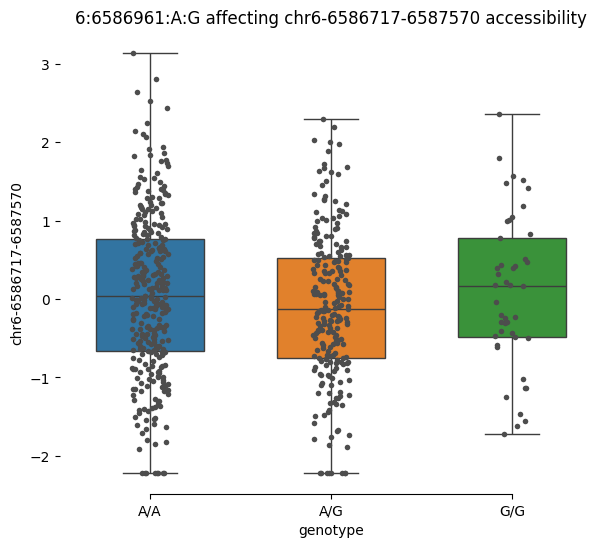

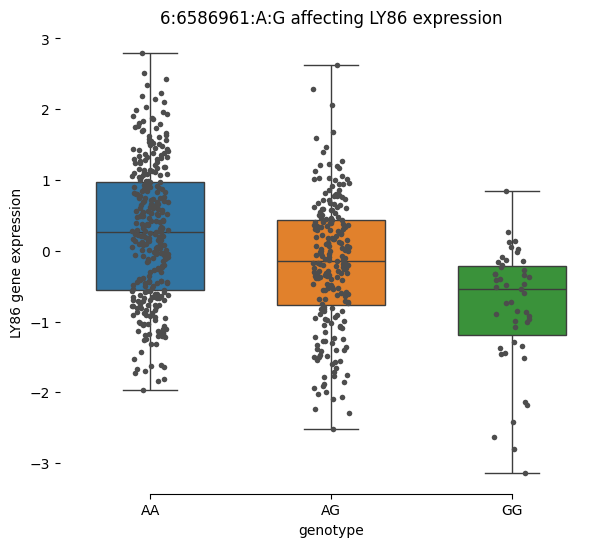

<Figure size 1000x600 with 0 Axes>

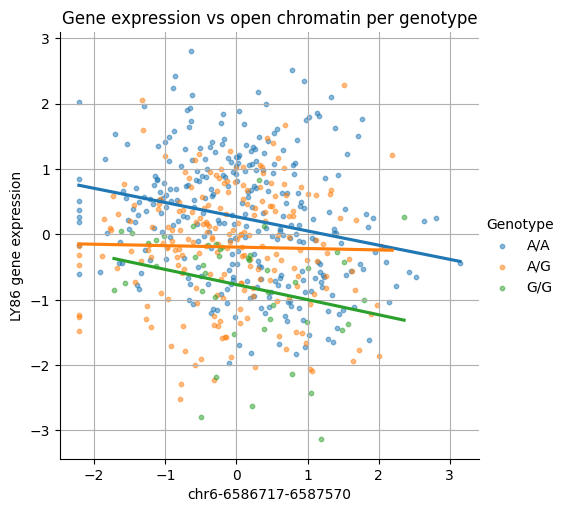

<Figure size 1000x600 with 0 Axes>

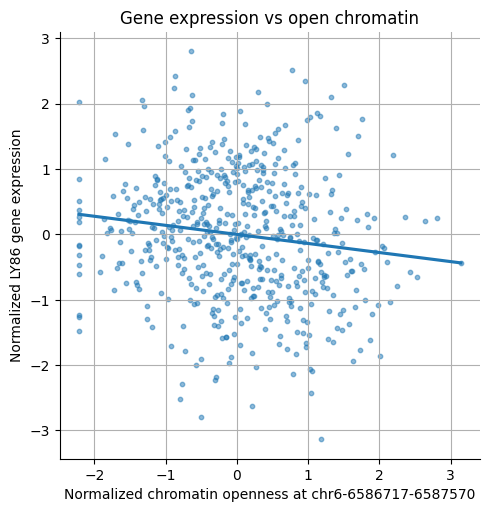

<Figure size 1000x600 with 0 Axes>

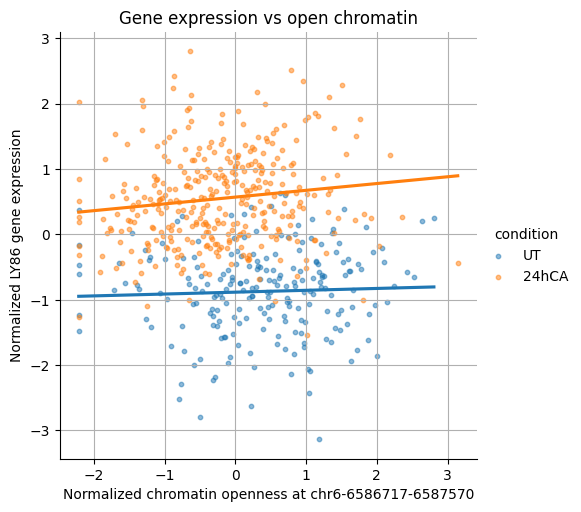

In [41]:
# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="Genotype", y="omics", hue="Genotype", data=caqtl_table_b, whis=[0, 100], width=.6).set(title = ' '.join(['6:6586961:A:G', 'affecting', 'chr6-6586717-6587570', 'accessibility']))
# Add in points to show each observation
sp = sns.stripplot(x="Genotype", y="omics", data=caqtl_table_b, size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='chr6-6586717-6587570', xlabel='genotype')
sns.despine(trim=True, left=True)
f.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_b_ly86_caqtl.pdf')

# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="Genotype", y="omics", hue="Genotype", data=eqtl_b_table, whis=[0, 100], width=.6).set(title = ' '.join(['6:6586961:A:G', 'affecting', 'LY86', 'expression']))
# Add in points to show each observation
sp = sns.stripplot(x="Genotype", y="omics", data=eqtl_b_table, size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='LY86 gene expression', xlabel='genotype')
sns.despine(trim=True, left=True)
f.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_b_ly86_eqtl.pdf')

# plot the interaction
plt.figure(figsize=(10, 6))
sns_p = sns.lmplot(data=interaction_table_b, x='omics2', y='omics1', hue='Genotype', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin per genotype')
plt.xlabel('chr6-6586717-6587570')
plt.ylabel('LY86 gene expression')
plt.grid(True)
plt.show()
sns_p.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_b_ly86_interaction_gt.pdf')

# plot the without the interaction
plt.figure(figsize=(10, 6))
sns_p = sns.lmplot(data=interaction_table_b, x='omics2', y='omics1', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin')
plt.xlabel('Normalized chromatin openness at chr6-6586717-6587570')
plt.ylabel('Normalized LY86 gene expression')
plt.grid(True)
plt.show()
sns_p.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_b_ly86_interaction.pdf')

plt.figure(figsize=(10, 6))
sns_p = sns.lmplot(data=interaction_table_b, x='omics2', y='omics1', hue='condition', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin')
plt.xlabel('Normalized chromatin openness at chr6-6586717-6587570')
plt.ylabel('Normalized LY86 gene expression')
plt.grid(True)
plt.show()
sns_p.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_b_ly86_interaction_condition_condition.pdf')


/local/4738904/ipykernel_348041/3625342558.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sb = sns.boxplot(x="Genotype", y="omics", hue="Genotype", data=caqtl_table_b[caqtl_table['condition'] == 'UT'], whis=[0, 100], width=.6).set(title = ' '.join(['6:6586961:A:G', 'affecting', 'chr6-6586717-6587570', 'accessibility', 'in UT']))


KeyError: 'condition'

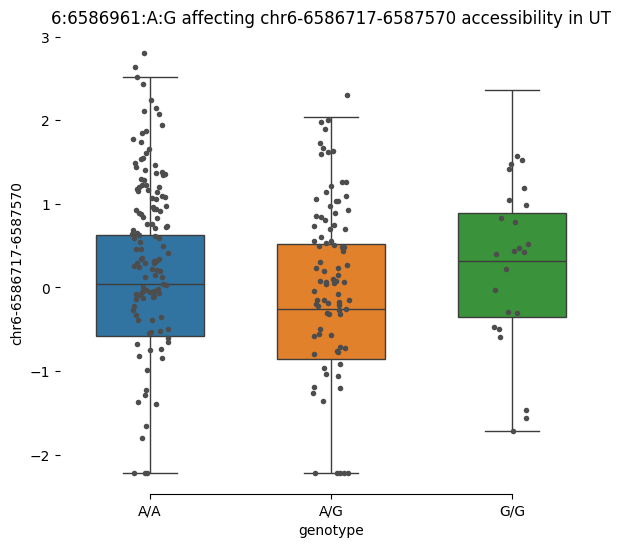

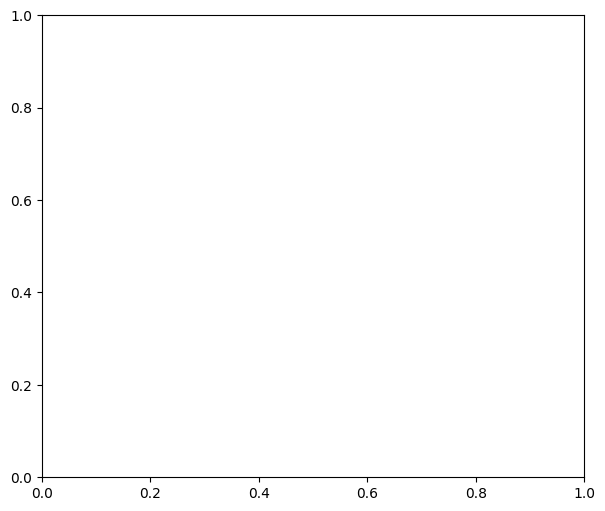

In [43]:
# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="Genotype", y="omics", hue="Genotype", data=caqtl_table_b[caqtl_table['condition'] == 'UT'], whis=[0, 100], width=.6).set(title = ' '.join(['6:6586961:A:G', 'affecting', 'chr6-6586717-6587570', 'accessibility', 'in UT']))
# Add in points to show each observation
sp = sns.stripplot(x="Genotype", y="omics", data=caqtl_table_b[caqtl_table_b['condition'] == 'UT'], size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='chr6-6586717-6587570', xlabel='genotype')
sns.despine(trim=True, left=True)
f.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_b_ly86_caqtl_ut.pdf')

# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="Genotype", y="omics", hue="Genotype", data=eqtl_table_b[eqtl_table_b['condition'] == 'UT'], whis=[0, 100], width=.6).set(title = ' '.join(['6:6586961:A:G', 'affecting', 'LY86', 'expression', 'in UT']))
# Add in points to show each observation
sp = sns.stripplot(x="Genotype", y="omics", data=eqtl_table_b[eqtl_table_b['condition'] == 'UT'], size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='LY86 gene expression', xlabel='genotype')
sns.despine(trim=True, left=True)
f.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_b_ly86_eqtl_ut.pdf')

# plot the interaction
plt.figure(figsize=(10, 6))
sns_p = sns.lmplot(data=interaction_table_b[interaction_table_b['condition'] == 'UT'], x='omics2', y='omics1', hue='Genotype', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin per genotype in UT')
plt.xlabel('chr6-6586717-6587570')
plt.ylabel('LY86 gene expression')
plt.grid(True)
plt.show()
sns_p.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_b_ly86_interaction_gt_ut.pdf')

# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="Genotype", y="omics", hue="Genotype", data=caqtl_table_b[caqtl_table_b['condition'] == '24hCA'], whis=[0, 100], width=.6).set(title = ' '.join(['6:6586961:A:G', 'affecting', 'chr6-6586717-6587570', 'accessibility', 'in 24hCA']))
# Add in points to show each observation
sp = sns.stripplot(x="Genotype", y="omics", data=caqtl_table_b[caqtl_table_b['condition'] == '24hCA'], size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='chr6-6586717-6587570', xlabel='genotype')
sns.despine(trim=True, left=True)
f.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_b_ly86_caqtl_24hca.pdf')

# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="Genotype", y="omics", hue="Genotype", data=eqtl_b_table[eqtl_b_table['condition'] == '24hCA'], whis=[0, 100], width=.6).set(title = ' '.join(['6:6586961:A:G', 'affecting', 'LY86', 'expression', 'in 24hCA']))
# Add in points to show each observation
sp = sns.stripplot(x="Genotype", y="omics", data=eqtl_b_table[eqtl_b_table['condition'] == '24hCA'], size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='LY86 gene expression', xlabel='genotype')
sns.despine(trim=True, left=True)
f.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_b_ly86_eqtl_24hca.pdf')

# plot the interaction
plt.figure(figsize=(10, 6))
sns_p = sns.lmplot(data=interaction_table_b[interaction_table_b['condition'] == '24hCA'], x='omics2', y='omics1', hue='Genotype', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin per genotype in 24hCA')
plt.xlabel('chr6-6586717-6587570')
plt.ylabel('LY86 gene expression')
plt.grid(True)
plt.show()
sns_p.savefig('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/plots/mo_b_ly86_interaction_gt_24hca.pdf')


In [36]:
caqtl_table_b

,sample,omics,genotype_id,phenotype_id,genotype,Genotype,sample_lane_x,condition_x,sample_lane_y,condition_y
0,MO1108;;230112_lane6,-1.285366,MO1108,MO1108;;230112_lane6,0.0,A/A,MO1108;;230112_lane6,UT,MO1108;;230112_lane6,UT
1,MO162;;230302_lane1,1.493810,MO162,MO162;;230302_lane1,0.0,A/A,MO162;;230302_lane1,UT,MO162;;230302_lane1,UT
2,MO1001;;230112_lane6,0.033484,MO1001,MO1001;;230112_lane6,0.0,A/A,MO1001;;230112_lane6,24hCA,MO1001;;230112_lane6,24hCA
3,MO204;;230105_lane1,-0.008369,MO204,MO204;;230105_lane1,0.0,A/A,MO204;;230105_lane1,24hCA,MO204;;230105_lane1,24hCA
4,UGLI020856;;230112_lane5,1.822050,UGLI020856,UGLI020856;;230112_lane5,0.0,A/A,UGLI020856;;230112_lane5,24hCA,UGLI020856;;230112_lane5,24hCA
...,...,...,...,...,...,...,...,...,...,...
584,MO209;;230316_lane6,-0.588903,MO209,MO209;;230316_lane6,2.0,G/G,MO209;;230316_lane6,UT,MO209;;230316_lane6,UT
585,UGLI035866;;230223_lane2,-0.033484,UGLI035866,UGLI035866;;230223_lane2,2.0,G/G,UGLI035866;;230223_lane2,UT,UGLI035866;;230223_lane2,UT
586,MO66;;230127_lane2,0.168177,MO66,MO66;;230127_lane2,2.0,G/G,MO66;;230127_lane2,24hCA,MO66;;230127_lane2,24hCA
587,UGLI022566;;230202_lane3,-1.017642,UGLI022566,UGLI022566;;230202_lane3,2.0,G/G,UGLI022566;;230202_lane3,24hCA,UGLI022566;;230202_lane3,24hCA


In [ ]:
# read the NC2022 v2 data
rna_data_nc2022_loc = '/groups/umcg-franke-scrna/tmp04/projects/sc-eqtlgen-consortium-pipeline/ongoing/wg3/wg3_Franke_split_v2/input/L1/Mono.qtlInput.txt'
rna_data_nc2022 = pd.read_csv(rna_data_nc2022_loc, header = 0, sep = '\t', index_col = 0)
# and the genotypes
plink_files_nc2022_base_loc = '/groups/umcg-franke-scrna/tmp04/projects/sc-eqtlgen-consortium-pipeline/ongoing/wg3/wg3_Franke_split_v2/genotype_input/EUR_imputed_hg38_varFiltered_chr3.bed'
genotypes_nc2022 = read_plink1_bin(plink_files_nc2022_base_loc)
# and smf
rna_nc2022_smf_loc = '/groups/umcg-franke-scrna/tmp04/projects/sc-eqtlgen-consortium-pipeline/ongoing/wg3/wg3_Franke_split_v2/input/smf.txt'
rna_nc2022_smf = pd.read_csv(rna_nc2022_smf_loc, header = 0, sep = '\t')

In [ ]:
# get the eQTL table
eqtl_nc2022_table = get_qtl_table(omics=rna_data_nc2022, 
                 genotypes=genotypes_nc2022, 
                 omics_smf=rna_nc2022_smf, 
                 omics_feature='PROK2', 
                 variant='3:71800545:A:G')
# add a binary genotype
eqtl_nc2022_table['alleles'] = eqtl_nc2022_table['genotype'].map({0.0 : 'AA', 1.0 : 'AG', 2.0 : 'GG'})
# and sort
eqtl_nc2022_table = eqtl_nc2022_table.sort_values('alleles')

In [ ]:
# read the nc2022_v3 v2 data
rna_data_nc2022_v3_loc = '/groups/umcg-franke-scrna/tmp04/projects/sc-eqtlgen-consortium-pipeline/ongoing/wg3/wg3_Franke_split_v3/input/L1/Mono.qtlInput.txt'
rna_data_nc2022_v3 = pd.read_csv(rna_data_nc2022_v3_loc, header = 0, sep = '\t', index_col = 0)
# and the genotypes
plink_files_nc2022_v3_base_loc = '/groups/umcg-franke-scrna/tmp04/projects/sc-eqtlgen-consortium-pipeline/ongoing/wg3/wg3_Franke_split_v3/genotype_input/EUR_imputed_hg38_varFiltered_chr3.bed'
genotypes_nc2022_v3 = read_plink1_bin(plink_files_nc2022_v3_base_loc)
# and smf
rna_nc2022_v3_smf_loc = '/groups/umcg-franke-scrna/tmp04/projects/sc-eqtlgen-consortium-pipeline/ongoing/wg3/wg3_Franke_split_v3/input/smf.txt'
rna_nc2022_v3_smf = pd.read_csv(rna_nc2022_v3_smf_loc, header = 0, sep = '\t')

In [ ]:
# get the eQTL table
eqtl_nc2022_v3_table = get_qtl_table(omics=rna_data_nc2022_v3, 
                 genotypes=genotypes_nc2022_v3, 
                 omics_smf=rna_nc2022_v3_smf, 
                 omics_feature='PROK2', 
                 variant='3:71800545:A:G')
# add a binary genotype
eqtl_nc2022_v3_table['alleles'] = eqtl_nc2022_v3_table['genotype'].map({0.0 : 'AA', 1.0 : 'AG', 2.0 : 'GG'})
# and sort
eqtl_nc2022_v3_table = eqtl_nc2022_v3_table.sort_values('alleles')

In [ ]:
# read the onek1k v2 data
rna_data_onek1k_loc = '/groups/umcg-franke-scrna/tmp04/projects/sc-eqtlgen-consortium-pipeline/ongoing/wg3/wg3_oneK1k/input/L1/Mono.qtlInput.PcCorrectedResiduals.txt.gz'
rna_data_onek1k = pd.read_csv(rna_data_onek1k_loc, header = 0, sep = '\t', index_col = 0)
# and the genotypes
plink_files_onek1k_base_loc = '/groups/umcg-franke-scrna/tmp04/projects/sc-eqtlgen-consortium-pipeline/ongoing/GRN-reconstruction/oneK1K/genotype_input/EUR_imputed_hg38_varFiltered_chr3.bed'
genotypes_onek1k = read_plink1_bin(plink_files_onek1k_base_loc)
# and smf
rna_onek1k_smf_loc = '/groups/umcg-franke-scrna/tmp04/projects/sc-eqtlgen-consortium-pipeline/ongoing/wg3/wg3_oneK1k/input/smf.txt'
rna_onek1k_smf = pd.read_csv(rna_onek1k_smf_loc, header = 0, sep = '\t', dtype = str)

In [ ]:
# get the eQTL table
eqtl_onek1k_table = get_qtl_table(omics=rna_data_onek1k, 
                 genotypes=genotypes_onek1k, 
                 omics_smf=rna_onek1k_smf, 
                 omics_feature='PROK2', 
                 variant='3:71800545:A:G')
# add a binary genotype
eqtl_onek1k_table['alleles'] = eqtl_onek1k_table['genotype'].map({0.0 : 'AA', 1.0 : 'AG', 2.0 : 'GG'})
# and sort
eqtl_onek1k_table = eqtl_onek1k_table.sort_values('alleles')

In [ ]:
# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="alleles", y="omics", hue="alleles", data=eqtl_onek1k_table, whis=[0, 100], width=.6).set(title = ' '.join(['3:71800545:A:G', 'affecting', 'PROK2', 'expression in OneK1K']))
# Add in points to show each observation
sp = sns.stripplot(x="alleles", y="omics", data=eqtl_onek1k_table, size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='PROK2 gene expression', xlabel='genotype')
sns.despine(trim=True, left=True)

# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="alleles", y="omics", hue="alleles", data=eqtl_nc2022_table, whis=[0, 100], width=.6).set(title = ' '.join(['3:71800545:A:G', 'affecting', 'PROK2', 'expression in Franke v2']))
# Add in points to show each observation
sp = sns.stripplot(x="alleles", y="omics", data=eqtl_nc2022_table, size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='PROK2 gene expression', xlabel='genotype')
sns.despine(trim=True, left=True)

# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="alleles", y="omics", hue="alleles", data=eqtl_nc2022_v3_table, whis=[0, 100], width=.6).set(title = ' '.join(['3:71800545:A:G', 'affecting', 'PROK2', 'expression in Franke v3']))
# Add in points to show each observation
sp = sns.stripplot(x="alleles", y="omics", data=eqtl_nc2022_v3_table, size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='PROK2 gene expression', xlabel='genotype')
sns.despine(trim=True, left=True)


In [ ]:
# make the eQTL caQTL overlap
interaction_table = get_interaction_table(omics_1=rna_data, 
                 omics_2=atac_data, 
                 genotypes=genotypes, 
                 omics_1_smf=rna_smf, 
                 omics_2_smf=atac_smf, 
                 omics_1_feature='AL157786.1', 
                 omics_2_feature='chr10-112389126-112390073', 
                 variant='10:112347540:T:C')
# add a binary genotype
interaction_table['alleles'] = interaction_table['genotype'].map({0.0 : 'TT', 1.0 : 'TC', 2.0 : 'CC'})
interaction_table = interaction_table.sort_values('alleles')

In [ ]:
# remove personal information
interaction_table = interaction_table.drop(labels = ['sample', 'genotype_id', 'genotype_id', 'genotype', 'phenotype_id'], axis = 1)
# rename some
interaction_table = interaction_table.rename({'omics1' : 'RNA', 'omics2' : 'ATAC'}, axis = 1)
# write the input of this table somewhere
interaction_table.to_csv('/groups/umcg-franke-scrna/tmp04/users/umcg-roelen/singularity/rstudio-server/simulated_home/ashg_qtl_overlap_example.tsv.gz', sep = '\t', index = False, header = True, compression = 'gzip')

In [ ]:
# location of the ATAC data
atac_data_imputed_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/caqtl/sc-eqtlgen/input/L1/imputed/UT/monocyte.qtlInput.txt.gz'
# read the ATAC data
atac_data_imputed = pd.read_csv(atac_data_imputed_loc, header = 0, sep = '\t', index_col = 0)

In [ ]:
# replace columns
atac_data_imputed.columns = list(map(lambda x: x.replace('-lane', '_lane'), atac_data_imputed.columns.tolist()))

In [ ]:
# check imputed vs non-imputed
interaction_table = get_interaction_table(omics_1=rna_data, 
                 omics_2=atac_data, 
                 genotypes=genotypes, 
                 omics_1_smf=rna_smf, 
                 omics_2_smf=atac_smf, 
                 omics_1_feature='RHD', 
                 omics_2_feature='chr1-25267721-25268401', 
                 variant='3:71800545:A:G')
# plot the without the interaction
plt.figure(figsize=(10, 6))
sns.lmplot(data=interaction_table, x='omics2', y='omics1', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin')
plt.xlabel('Normalized chromatin openness at chr1-25267721-25268401')
plt.ylabel('Normalized RHD gene expression')
plt.grid(True)
plt.show()
interaction_table = get_interaction_table(omics_1=rna_data, 
                 omics_2=atac_data_imputed, 
                 genotypes=genotypes, 
                 omics_1_smf=rna_smf, 
                 omics_2_smf=atac_smf, 
                 omics_1_feature='RHD', 
                 omics_2_feature='chr1-25267721-25268401', 
                 variant='3:71800545:A:G')
# plot the without the interaction
plt.figure(figsize=(10, 6))
sns.lmplot(data=interaction_table, x='omics2', y='omics1', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin')
plt.xlabel('Normalized chromatin openness at chr1-25267721-25268401')
plt.ylabel('Normalized RHD gene expression')
plt.grid(True)
plt.show()

In [ ]:
# location of the expression data
rna_nk_data_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/eqtl/sc-eqtlgen/input/L1/UT/NK.qtlInput.PcCorrectedResiduals.txt.gz'
# read the RNA data
rna_nk_data = pd.read_csv(rna_nk_data_loc, header = 0, sep = '\t', index_col = 0)

In [ ]:
# location of the ATAC data
atac_nk_data_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/caqtl/sc-eqtlgen/input/L1/UT/NK.qtlInput.txt.gz'
# read the ATAC data
atac_nk_data = pd.read_csv(atac_nk_data_loc, header = 0, sep = '\t', index_col = 0)

In [ ]:
# the location of the CRE output
nk_cre_output_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/eQTA/creQTL_full/L1/UT/NK/top_iqtl_results_aggregated.txt'
# load that file
nk_cre_output = pd.read_csv(nk_cre_output_loc, header = 0, sep = '\t')
#interaction_plots_to_list(rna_nk_data, atac_nk_data, rna_smf, atac_smf, genotypes, plot_queries=[InteractionPlotQuery(gene, region, variant)])

In [ ]:
# get the top 10 significant ones
nk_cre_output_top10 = top_creqtls_to_queries(nk_cre_output, how_many = 20)
# and print those
interaction_plots_to_list(rna_nk_data, atac_nk_data, rna_smf, atac_smf, genotypes, plot_queries = nk_cre_output_top10)